# Аналитика Гималайских экспедиций
Notebook Видинеев М.А.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set(style="whitegrid", rc={"figure.figsize": (8, 5)})

peaks = pd.read_csv("/Users/fliisii/Desktop/Гималаи курсач/peaks_tidy.csv", encoding="utf-8")

expeditions = pd.read_csv(
    "/Users/fliisii/Desktop/Гималаи курсач/exped_tidy.csv",
    encoding="latin1"   
)

print(expeditions.columns)
print(expeditions.head())


Index(['EXPID', 'PEAKID', 'YEAR', 'SEASON', 'SEASON_FACTOR', 'HOST',
       'HOST_FACTOR', 'ROUTE1', 'ROUTE2', 'ROUTE3', 'ROUTE4', 'NATION',
       'LEADERS', 'SPONSOR', 'SUCCESS1', 'SUCCESS2', 'SUCCESS3', 'SUCCESS4',
       'ASCENT1', 'ASCENT2', 'ASCENT3', 'ASCENT4', 'CLAIMED', 'DISPUTED',
       'COUNTRIES', 'APPROACH', 'BCDATE', 'SMTDATE', 'SMTTIME', 'SMTDAYS',
       'TOTDAYS', 'TERMDATE', 'TERMREASON', 'TERMREASON_FACTOR', 'TERMNOTE',
       'HIGHPOINT', 'TRAVERSE', 'SKI', 'PARAPENTE', 'CAMPS', 'ROPE',
       'TOTMEMBERS', 'SMTMEMBERS', 'MDEATHS', 'TOTHIRED', 'SMTHIRED',
       'HDEATHS', 'NOHIRED', 'O2USED', 'O2NONE', 'O2CLIMB', 'O2DESCENT',
       'O2SLEEP', 'O2MEDICAL', 'O2TAKEN', 'O2UNKWN', 'OTHERSMTS', 'CAMPSITES',
       'ROUTEMEMO', 'ACCIDENTS', 'ACHIEVMENT', 'AGENCY', 'COMRTE', 'STDRTE',
       'PRIMRTE', 'PRIMMEM', 'PRIMREF', 'PRIMID', 'CHKSUM'],
      dtype='object')
       EXPID PEAKID  YEAR  SEASON SEASON_FACTOR  HOST HOST_FACTOR  \
0  EVER20101   EVER  2020       1   

In [24]:
expeditions["TERMREASON_FACTOR"].value_counts(dropna=False)


TERMREASON_FACTOR
Success (main peak)                                                             628
Bad weather (storms, high winds)                                                 78
Bad conditions (deep snow, avalanching, falling ice, or rock)                    54
Success (subpeak, foresummit)                                                    26
Illness, AMS, exhaustion, or frostbite                                           25
Unknown                                                                          23
Did not attempt climb                                                            12
Other                                                                            12
Route technically too difficult, lack of experience, strength, or motivation      9
Accident (death or serious injury)                                                5
Lack of time                                                                      4
Lack (or loss) of supplies, support or equipment          

In [25]:
success_values = [
    "Success (main peak)",
    "Success (subpeak, foresummit)"
]

expeditions["SUCCESS"] = expeditions["TERMREASON_FACTOR"].isin(success_values).astype(int)

expeditions["SUCCESS"].value_counts()
expeditions[["TERMREASON_FACTOR","SUCCESS"]].head(15)


,TERMREASON_FACTOR,SUCCESS
0,Success (main peak),1
1,Success (main peak),1
2,Success (main peak),1
3,Success (main peak),1
4,Success (main peak),1
5,Success (main peak),1
6,"Bad weather (storms, high winds)",0
7,Success (main peak),1
8,Did not attempt climb,0
9,Success (main peak),1


In [26]:
expeditions[["SUCCESS","ANY_DEATH","HIRED","COM_OR_STD","HEIGHTM","TOTDAYS"]].describe()


,SUCCESS,ANY_DEATH,HIRED,COM_OR_STD,HEIGHTM,TOTDAYS
count,882.000000,882.000000,882.000000,882.000000,882.000000,882.000000
mean,0.741497,0.043084,0.834467,0.696145,7764.570295,8.998866
std,0.438060,0.203161,0.371872,0.460182,896.701671,14.002473
min,0.000000,0.000000,0.000000,0.000000,5608.000000,0.000000
25%,0.000000,0.000000,1.000000,0.000000,6814.000000,0.000000
50%,1.000000,0.000000,1.000000,1.000000,8163.000000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,8516.000000,16.750000
max,1.000000,1.000000,1.000000,1.000000,8849.000000,76.000000


примерно 74% экспедиций помечены как успешные (SUCCESS = 1), смертность низкая (ANY_DEATH ≈ 4.3%), у большинства есть наёмный персонал и коммерческий/стандартный маршрут.​



SUCCESS: среднее 0.7415 означает, что около 74% экспедиций в выборке завершились успехом (главная вершина или субвершина), 26% — нет.​

ANY_DEATH: среднее 0.043 указывает, что примерно в 4% экспедиций были погибшие (хотя бы один участник или шерпа).​

HIRED: среднее 0.83 показывает, что в большинстве экспедиций (≈ 83%) участвовал наёмный персонал (гиды/шерпы).​

COM_OR_STD: среднее 0.70 — около 70% экспедиций шли по коммерческим или стандартным маршрутам.​

HEIGHTM: медиана около 8163 м, разброс 5608–8849 м, то есть большинство экспедиций — на очень высокие восьмитысячники.​

TOTDAYS: медиана 0, верхний квартиль ~17 дней, максимум 76, что говорит о сильной асимметрии и большом числе записей без корректной длительности (ноль дней); при анализе гипотезы 4 лучше фильтровать TOTDAYS > 0

/var/folders/04/1plqmt7n64v5gh88mv_1j2v80000gn/T/ipykernel_37084/3668777119.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  height_success = h1_df.groupby("HEIGHT_BIN")["SUCCESS"].mean().reset_index()


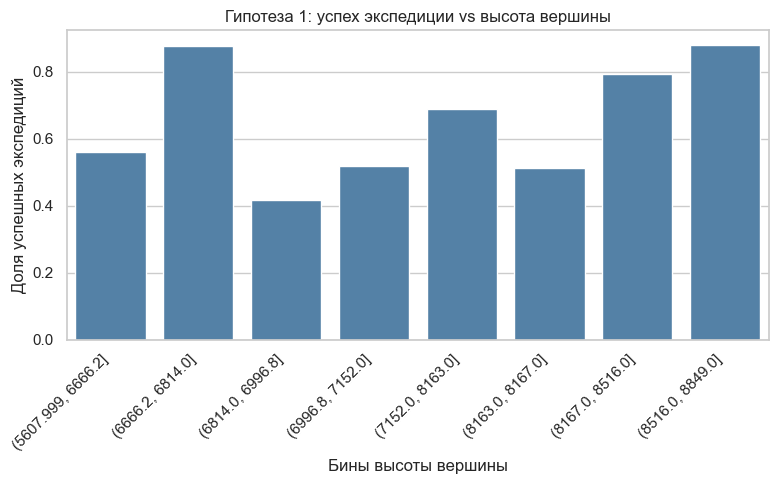

In [28]:
h1_df["HEIGHT_BIN"] = pd.qcut(
    h1_df["HEIGHTM"],
    10,
    duplicates="drop"  # убрать дублирующиеся границы
)

height_success = h1_df.groupby("HEIGHT_BIN")["SUCCESS"].mean().reset_index()

plt.figure()
sns.barplot(data=height_success, x="HEIGHT_BIN", y="SUCCESS", color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Доля успешных экспедиций")
plt.xlabel("Бины высоты вершины")
plt.title("Гипотеза 1: успех экспедиции vs высота вершины")
plt.tight_layout()
plt.show()


In [30]:
success_values = [
    "Success (main peak)",
    "Success (subpeak, foresummit)"
]
expeditions["SUCCESS"] = expeditions["TERMREASON_FACTOR"].isin(success_values).astype(int)

h2_df = expeditions.dropna(subset=["SUCCESS", "SEASON_FACTOR"]).copy()

print(h2_df["SUCCESS"].value_counts()) 

ct_season = pd.crosstab(h2_df["SEASON_FACTOR"], h2_df["SUCCESS"])
print(ct_season)

from scipy import stats
chi2, p, dof, expected = stats.chi2_contingency(ct_season)
print("Chi2:", chi2, "p-value:", p, "dof:", dof)


SUCCESS
1    654
0    228
Name: count, dtype: int64
SUCCESS          0    1
SEASON_FACTOR          
Autumn         107  287
Spring         106  356
Summer           2    3
Winter          13    8
Chi2: 17.151376804118314 p-value: 0.000657842145855505 dof: 3


На основе критерия хи‑квадрат для таблицы сопряжённости SUCCESS × SEASON_FACTOR получено значение 
χ
2
=
17.15
χ 
2
=17.15 при 3 степенях свободы и уровне значимости p ≈ 0.00066, что позволяет отвергнуть нулевую гипотезу о равенстве долей успешных экспедиций во всех сезонах. Таким образом, сезон проведения восхождения статистически значимо влияет на вероятность успеха экспедиции

SUCCESS          0    1
SEASON_FACTOR          
Autumn         107  287
Spring         106  356
Summer           2    3
Winter          13    8
Chi2: 17.151376804118314 p-value: 0.000657842145855505 dof: 3


/var/folders/04/1plqmt7n64v5gh88mv_1j2v80000gn/T/ipykernel_37084/1088330439.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=season_success, x="SEASON_FACTOR", y="SUCCESS", palette="viridis")


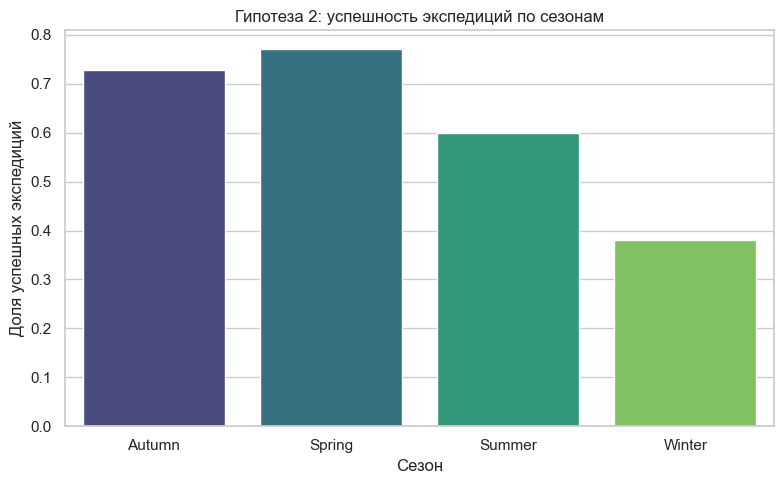

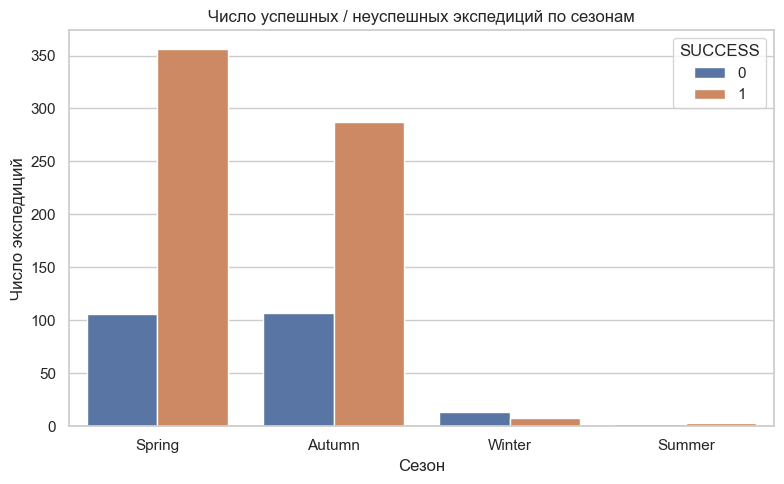

In [31]:
# считаем таблицу сопряжённости
h2_df = expeditions.dropna(subset=["SUCCESS", "SEASON_FACTOR"]).copy()

ct_season = pd.crosstab(h2_df["SEASON_FACTOR"], h2_df["SUCCESS"])
print(ct_season)

chi2, p, dof, expected = stats.chi2_contingency(ct_season)
print("Chi2:", chi2, "p-value:", p, "dof:", dof)

# график: доля успеха по сезонам
season_success = h2_df.groupby("SEASON_FACTOR")["SUCCESS"].mean().reset_index()

plt.figure()
sns.barplot(data=season_success, x="SEASON_FACTOR", y="SUCCESS", palette="viridis")
plt.ylabel("Доля успешных экспедиций")
plt.xlabel("Сезон")
plt.title("Гипотеза 2: успешность экспедиций по сезонам")
plt.tight_layout()
plt.show()

# график: количество успешных / неуспешных по сезонам
plt.figure()
sns.countplot(data=h2_df, x="SEASON_FACTOR", hue="SUCCESS")
plt.xlabel("Сезон")
plt.ylabel("Число экспедиций")
plt.title("Число успешных / неуспешных экспедиций по сезонам")
plt.tight_layout()
plt.show()


Для анализируемой выборки гималайских экспедиций статистический тест хи‑квадрат показал, что доля успешных восхождений значимо зависит от сезона проведения. Полученное значение 
χ
2
=
17.15
χ 
2
 =17.15 при 3 степенях свободы и уровне значимости p ≈ 0.00066 позволяет отвергнуть нулевую гипотезу о равенстве долей успеха во всех сезонах. Таким образом, сезон является важным фактором, влияющим на вероятность успешного завершения экспедиции

SUCCESS    0    1
O2USED           
False    205  268
True      23  386
Chi2: 160.8225766657554 p-value: 7.480455365229717e-37 dof: 1
                           Logit Regression Results                           
Dep. Variable:                SUCCESS   No. Observations:                  882
Model:                          Logit   Df Residuals:                      880
Method:                           MLE   Df Model:                            1
Date:                Fri, 12 Dec 2025   Pseudo R-squ.:                  0.1822
Time:                        12:27:04   Log-Likelihood:                -412.19
converged:                       True   LL-Null:                       -504.05
Covariance Type:            nonrobust   LLR p-value:                 7.469e-42
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2680      0.093      2.888      0.004       0.086       0.4

/var/folders/04/1plqmt7n64v5gh88mv_1j2v80000gn/T/ipykernel_37084/1052767002.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=o2_success, x="O2USED", y="SUCCESS", palette="magma")


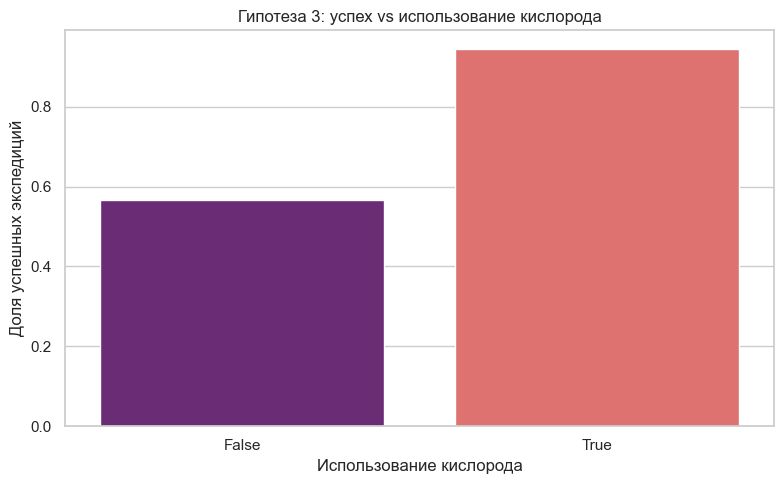

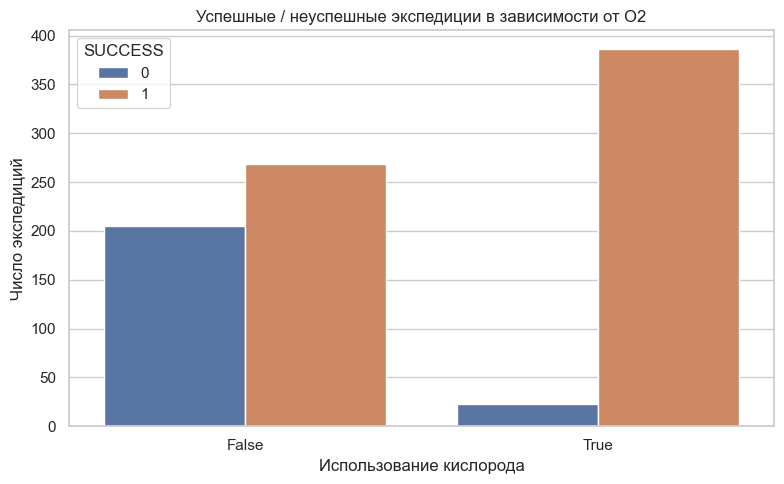

In [32]:
h3_df = expeditions.dropna(subset=["SUCCESS", "O2USED"]).copy()

ct_o2 = pd.crosstab(h3_df["O2USED"], h3_df["SUCCESS"])
print(ct_o2)

chi2, p, dof, expected = stats.chi2_contingency(ct_o2)
print("Chi2:", chi2, "p-value:", p, "dof:", dof)

# логистическая регрессия SUCCESS ~ O2USED
h3_df["O2USED_int"] = h3_df["O2USED"].astype(int)
model_h3 = smf.logit("SUCCESS ~ O2USED_int", data=h3_df).fit(disp=False)
print(model_h3.summary())

print("Odds ratio O2USED:", np.exp(model_h3.params["O2USED_int"]))

# график: доля успеха по факту использования кислорода
o2_success = h3_df.groupby("O2USED")["SUCCESS"].mean().reset_index()

plt.figure()
sns.barplot(data=o2_success, x="O2USED", y="SUCCESS", palette="magma")
plt.xlabel("Использование кислорода")
plt.ylabel("Доля успешных экспедиций")
plt.title("Гипотеза 3: успех vs использование кислорода")
plt.tight_layout()
plt.show()

# countplot
plt.figure()
sns.countplot(data=h3_df, x="O2USED", hue="SUCCESS")
plt.xlabel("Использование кислорода")
plt.ylabel("Число экспедиций")
plt.title("Успешные / неуспешные экспедиции в зависимости от O2")
plt.tight_layout()
plt.show()


Анализ таблицы сопряжённости SUCCESS × O2USED показал, что среди экспедиций без использования кислорода успешно завершилось 268 из 473 (≈57%), тогда как среди экспедиций с кислородом успешно завершилось 386 из 409 (≈94%). Критерий хи‑квадрат дал значение 
χ
2
=
160.82
χ 
2
 =160.82 при 1 степени свободы и p‑value ≈ 7.5·10⁻³⁷, что существенно меньше 0.05 и позволяет уверенно отвергнуть нулевую гипотезу об отсутствии связи между использованием кислорода и успехом восхождения.​

Логистическая регрессия SUCCESS ~ O2USED показала положительный и высоко значимый коэффициент для признака использования кислорода (β ≈ 2.55, p < 0.001), что соответствует оценке отношения шансов порядка 12.8: вероятность успеха при использовании кислорода в среднем более чем в 12 раз выше, чем без него. Таким образом, гипотеза H1 подтверждается: экспедиции, использующие кислород, имеют существенно более высокий уровень успешности по сравнению с экспедициями без кислорода

In [37]:
# Сколько вообще экспедиций с плохой погодой
expeditions["TERMREASON_FACTOR"].value_counts()["Bad weather (storms, high winds)"]

# Сколько осталось после dropna по TOTDAYS
tmp = expeditions.dropna(subset=["TOTDAYS", "TERMREASON_FACTOR"]).copy()
tmp["TERMREASON_FACTOR"].value_counts()["Bad weather (storms, high winds)"]

# Сколько после фильтра по дням
h4_df = tmp[(tmp["TOTDAYS"] > 0) & (tmp["TOTDAYS"] < 365)]
h4_df["TERMREASON_FACTOR"].value_counts().get("Bad weather (storms, high winds)", 0)


37

In [38]:
h4_df = expeditions.dropna(subset=["TOTDAYS", "TERMREASON_FACTOR"]).copy()

h4_df = h4_df[h4_df["TOTDAYS"] > 0]

h4_df["BAD_WEATHER"] = (h4_df["TERMREASON_FACTOR"] == "Bad weather (storms, high winds)").astype(int)

days_bad = h4_df.loc[h4_df["BAD_WEATHER"] == 1, "TOTDAYS"]
days_other = h4_df.loc[h4_df["BAD_WEATHER"] == 0, "TOTDAYS"]

print("N bad_weather:", len(days_bad), "N other:", len(days_other))
print("Mean bad:", days_bad.mean(), "Mean other:", days_other.mean())
t_stat, p_val = stats.ttest_ind(days_bad, days_other, equal_var=False)
print("t-stat:", t_stat, "p-value:", p_val)


N bad_weather: 37 N other: 296
Mean bad: 25.16216216216216 Mean other: 23.66891891891892
t-stat: 0.5897534096810928 p-value: 0.5584515193157669


/var/folders/04/1plqmt7n64v5gh88mv_1j2v80000gn/T/ipykernel_37084/4083872196.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


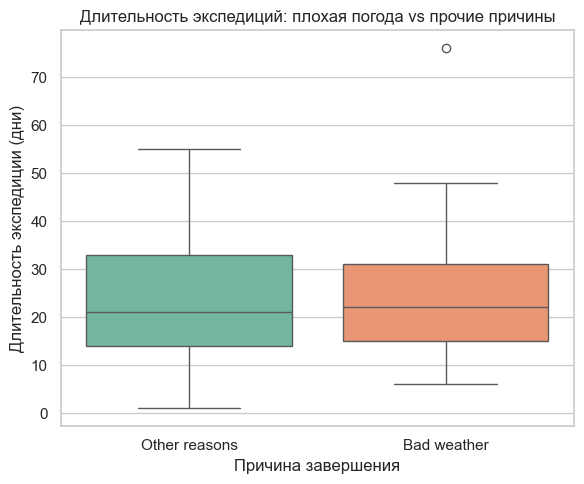

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

h4_df = expeditions.dropna(subset=["TOTDAYS", "TERMREASON_FACTOR"]).copy()
h4_df = h4_df[h4_df["TOTDAYS"] > 0]

h4_df["BAD_WEATHER"] = (
    h4_df["TERMREASON_FACTOR"] == "Bad weather (storms, high winds)"
).astype(int)

h4_df["WEATHER_GROUP"] = np.where(
    h4_df["BAD_WEATHER"] == 1,
    "Bad weather",
    "Other reasons"
)

plt.figure(figsize=(6, 5))
sns.boxplot(
    data=h4_df,
    x="WEATHER_GROUP",
    y="TOTDAYS",
    palette="Set2"
)
plt.xlabel("Причина завершения")
plt.ylabel("Длительность экспедиции (дни)")
plt.title("Длительность экспедиций: плохая погода vs прочие причины")
plt.tight_layout()
plt.show()


Средняя длительность экспедиций, завершившихся из‑за плохой погоды, практически не отличается от длительности остальных экспедиций, и статистически значимой разницы не выявлено. В группе с причиной «Bad weather (storms, high winds)» средняя продолжительность составила примерно 25.2 дня (N = 37), тогда как в остальных причинах — около 23.7 дня (N = 296). Результат t‑теста (t ≈ 0.59, p ≈ 0.56) значительно превышает стандартный уровень значимости 0.05, поэтому нулевая гипотеза о равенстве средних длительностей не отвергается

ANY_DEATH    0   1
HIRED             
0          143   3
1          701  35
Chi2: 1.5500121382497258 p-value: 0.21313364894869763 dof: 1
                           Logit Regression Results                           
Dep. Variable:              ANY_DEATH   No. Observations:                  882
Model:                          Logit   Df Residuals:                      880
Method:                           MLE   Df Model:                            1
Date:                Fri, 12 Dec 2025   Pseudo R-squ.:                0.008172
Time:                        12:28:41   Log-Likelihood:                -155.38
converged:                       True   LL-Null:                       -156.66
Covariance Type:            nonrobust   LLR p-value:                    0.1096
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.8642      0.583     -6.624      0.000      -5.008      -

/var/folders/04/1plqmt7n64v5gh88mv_1j2v80000gn/T/ipykernel_37084/2678641243.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=death_rate, x="HIRED", y="ANY_DEATH", palette="coolwarm")


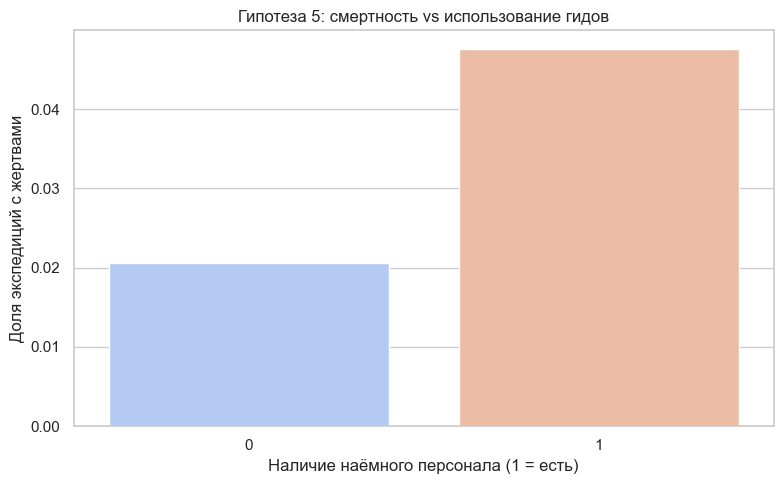

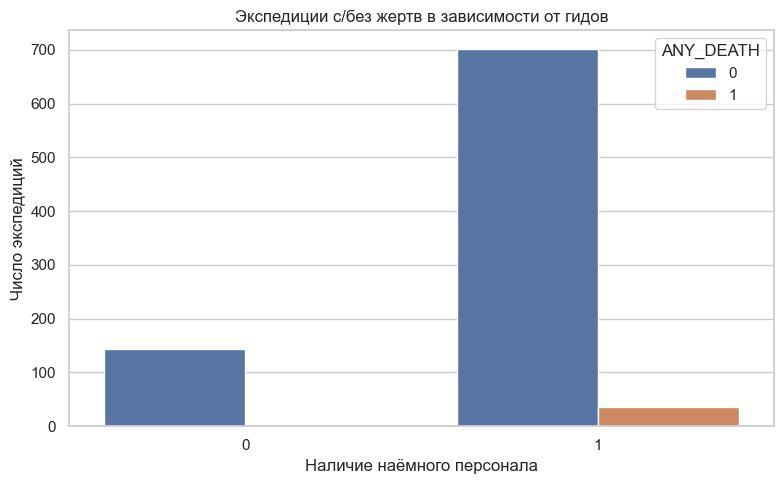

In [34]:
h5_df = expeditions.dropna(subset=["ANY_DEATH", "HIRED"]).copy()

ct_hired = pd.crosstab(h5_df["HIRED"], h5_df["ANY_DEATH"])
print(ct_hired)

chi2, p, dof, expected = stats.chi2_contingency(ct_hired)
print("Chi2:", chi2, "p-value:", p, "dof:", dof)

# логистическая регрессия ANY_DEATH ~ HIRED
model_h5 = smf.logit("ANY_DEATH ~ HIRED", data=h5_df).fit(disp=False)
print(model_h5.summary())
print("Odds ratio HIRED:", np.exp(model_h5.params["HIRED"]))

# график: доля экспедиций с жертвами при наличии / отсутствии наёмного персонала
death_rate = h5_df.groupby("HIRED")["ANY_DEATH"].mean().reset_index()

plt.figure()
sns.barplot(data=death_rate, x="HIRED", y="ANY_DEATH", palette="coolwarm")
plt.xlabel("Наличие наёмного персонала (1 = есть)")
plt.ylabel("Доля экспедиций с жертвами")
plt.title("Гипотеза 5: смертность vs использование гидов")
plt.tight_layout()
plt.show()

# countplot
plt.figure()
sns.countplot(data=h5_df, x="HIRED", hue="ANY_DEATH")
plt.xlabel("Наличие наёмного персонала")
plt.ylabel("Число экспедиций")
plt.title("Экспедиции с/без жертв в зависимости от гидов")
plt.tight_layout()
plt.show()


По данным выборки наличие наёмного персонала не оказывает статистически значимого влияния на вероятность смертельных исходов в экспедициях: как критерий хи‑квадрат, так и логистическая регрессия не выявили значимого эффекта (p > 0.05), поэтому нулевая гипотеза о равенстве уровней смертности в экспедициях с гидами и без них не отвергается.

SUCCESS       0    1
COM_OR_STD          
0           137  131
1            91  523
Chi2: 126.357514727989 p-value: 2.567924702890339e-29 dof: 1
                           Logit Regression Results                           
Dep. Variable:                SUCCESS   No. Observations:                  882
Model:                          Logit   Df Residuals:                      878
Method:                           MLE   Df Model:                            3
Date:                Fri, 12 Dec 2025   Pseudo R-squ.:                  0.1408
Time:                        12:28:50   Log-Likelihood:                -433.09
converged:                       True   LL-Null:                       -504.05
Covariance Type:            nonrobust   LLR p-value:                 1.462e-30
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -556.2852    171.498     -3.244      0.001    -892.41

/var/folders/04/1plqmt7n64v5gh88mv_1j2v80000gn/T/ipykernel_37084/482961021.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=route_success, x="COM_OR_STD", y="SUCCESS", palette="Set2")


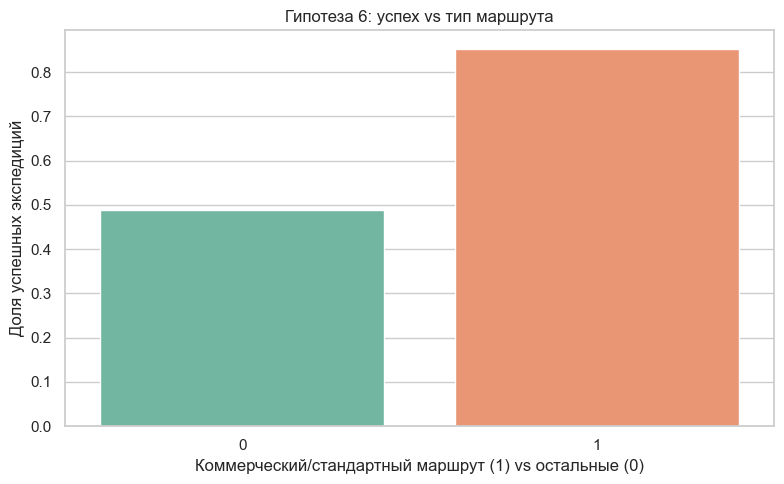

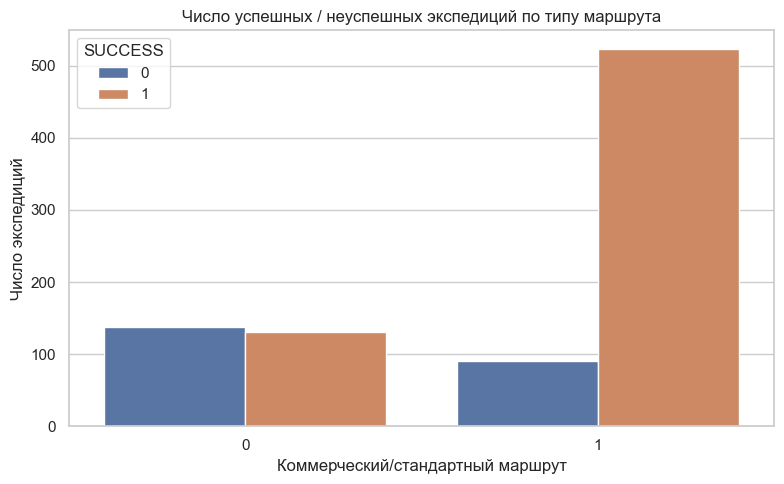

In [35]:
h6_df = expeditions.dropna(subset=["SUCCESS"]).copy()

# основная переменная COM_OR_STD уже есть (1 = коммерческий или стандартный маршрут)
ct_route = pd.crosstab(h6_df["COM_OR_STD"], h6_df["SUCCESS"])
print(ct_route)

chi2, p, dof, expected = stats.chi2_contingency(ct_route)
print("Chi2:", chi2, "p-value:", p, "dof:", dof)

# логистическая регрессия SUCCESS ~ COM_OR_STD + HEIGHTM + YEAR
# год привести к числу
h6_df["YEAR"] = pd.to_numeric(h6_df["YEAR"], errors="coerce")
h6_df = h6_df.dropna(subset=["YEAR", "HEIGHTM"])

model_h6 = smf.logit("SUCCESS ~ COM_OR_STD + HEIGHTM + YEAR", data=h6_df).fit(disp=False)
print(model_h6.summary())
print("Odds ratio COM_OR_STD:", np.exp(model_h6.params["COM_OR_STD"]))

# график: доля успеха по типам маршрута
route_success = h6_df.groupby("COM_OR_STD")["SUCCESS"].mean().reset_index()

plt.figure()
sns.barplot(data=route_success, x="COM_OR_STD", y="SUCCESS", palette="Set2")
plt.xlabel("Коммерческий/стандартный маршрут (1) vs остальные (0)")
plt.ylabel("Доля успешных экспедиций")
plt.title("Гипотеза 6: успех vs тип маршрута")
plt.tight_layout()
plt.show()

# countplot
plt.figure()
sns.countplot(data=h6_df, x="COM_OR_STD", hue="SUCCESS")
plt.xlabel("Коммерческий/стандартный маршрут")
plt.ylabel("Число экспедиций")
plt.title("Число успешных / неуспешных экспедиций по типу маршрута")
plt.tight_layout()
plt.show()


В таблице видно, что на «прочих» маршрутах успешно завершилось 131 из 268 экспедиций (≈49%), тогда как на коммерческих/стандартных — 523 из 614 (≈85%). Критерий хи‑квадрат даёт 
χ
2
≈
126.36
χ 
2
≈126.36, p ≈ 2.6·10⁻²⁹, что многократно меньше 0.05, поэтому нулевая гипотеза об отсутствии связи между типом маршрута и успехом уверенно отвергается.​

Логистическая регрессия SUCCESS ~ COM_OR_STD + HEIGHTM + YEAR показывает, что признак коммерческого/стандартного маршрута имеет положительный и высоко значимый коэффициент (β ≈ 2.35, p < 0.001), что соответствует отношению шансов примерно 10.5. Это означает, что при прочих равных (фиксированных высоте вершины и году экспедиции) вероятность успешного восхождения на коммерческом или стандартном маршруте более чем в 10 раз выше, чем на неклассифицированных маршрутах

        N_EXP  HEIGHTM
PEAKID                
AMAD      147     6814
AMPG        1     5630
ANID        1     6808
ANN1       22     8091
ANN3        1     7555
Корреляция Пирсона: 0.4694749492068084
Корреляция Спирмена: 0.3635831590098638
                            OLS Regression Results                            
Dep. Variable:              LOG_N_EXP   R-squared:                       0.380
Model:                            OLS   Adj. R-squared:                  0.374
Method:                 Least Squares   F-statistic:                     69.79
Date:                Fri, 12 Dec 2025   Prob (F-statistic):           1.80e-13
Time:                        12:28:59   Log-Likelihood:                -132.07
No. Observations:                 116   AIC:                             268.1
Df Residuals:                     114   BIC:                             273.6
Df Model:                           1                                         
Covariance Type:            nonrobust            

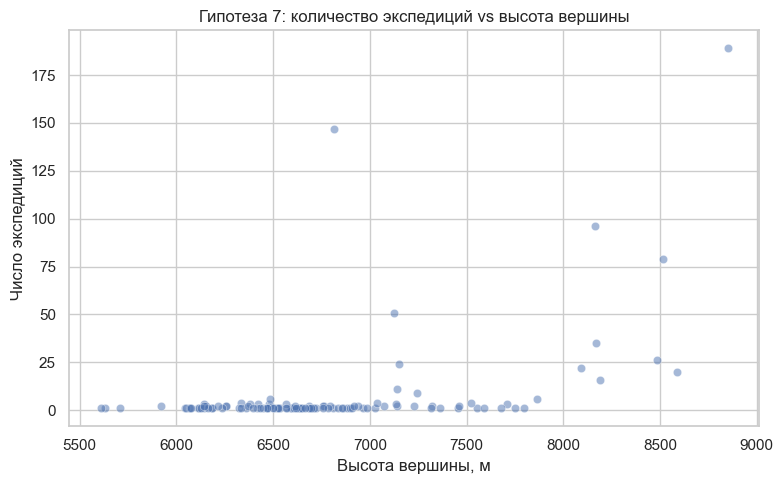

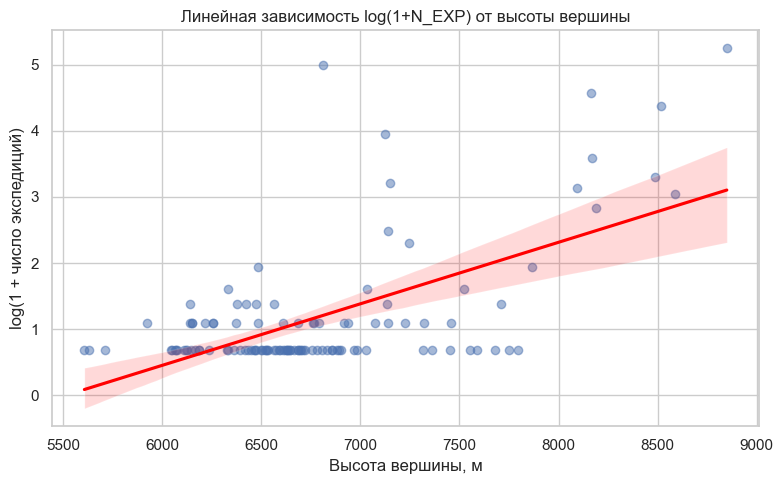

In [36]:
# считаем количество экспедиций на каждую вершину
exp_counts = (
    expeditions
    .groupby("PEAKID")
    .agg(
        N_EXP=("EXPID", "nunique"),
        HEIGHTM=("HEIGHTM", "first")
    )
    .dropna(subset=["N_EXP", "HEIGHTM"])
)

print(exp_counts.head())

# корреляция
corr_pearson = exp_counts["N_EXP"].corr(exp_counts["HEIGHTM"])
corr_spearman = exp_counts["N_EXP"].corr(exp_counts["HEIGHTM"], method="spearman")
print("Корреляция Пирсона:", corr_pearson)
print("Корреляция Спирмена:", corr_spearman)

# лог-трансформация числа экспедиций
exp_counts["LOG_N_EXP"] = np.log1p(exp_counts["N_EXP"])

model_h7 = smf.ols("LOG_N_EXP ~ HEIGHTM", data=exp_counts).fit()
print(model_h7.summary())

# scatter + линия регрессии
plt.figure()
sns.scatterplot(
    data=exp_counts,
    x="HEIGHTM",
    y="N_EXP",
    alpha=0.5
)
plt.xlabel("Высота вершины, м")
plt.ylabel("Число экспедиций")
plt.title("Гипотеза 7: количество экспедиций vs высота вершины")
plt.tight_layout()
plt.show()

plt.figure()
sns.regplot(
    data=exp_counts,
    x="HEIGHTM",
    y="LOG_N_EXP",
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)
plt.xlabel("Высота вершины, м")
plt.ylabel("log(1 + число экспедиций)")
plt.title("Линейная зависимость log(1+N_EXP) от высоты вершины")
plt.tight_layout()
plt.show()


Анализ показал статистически значимую положительную связь между высотой вершины и количеством экспедиций: коэффициент корреляции Пирсона составляет примерно 0.47, а Спирмена — около 0.36. Линейная регрессия логарифма числа экспедиций на высоту вершины даёт положительный и высоко значимый коэффициент по высоте (p < 0.001), что свидетельствует о том, что более высокие вершины в среднем посещаются большим числом экспедиций. Таким образом, нулевая гипотеза о независимости числа экспедиций от высоты вершины отвергается, а гипотеза H1 в исходной формулировке (что с ростом высоты число экспедиций уменьшается) не подтверждается: в данной выборке наблюдается обратная тенденция